In [19]:
import matplotlib.pyplot as pl
import numpy as np
import ot
from ot.gromov import gromov_wasserstein, fused_gromov_wasserstein

In [20]:
n = 20 
n2 = 30 
sig = 1 
sig2 = 0.1 

np.random.seed(0)

phi = np.arange(n)[:, None]
xs = phi + sig * np.random.randn(n, 1)
ys = np.vstack(
    (np.ones((n // 2, 1)), 0 * np.ones((n // 2, 1)))
) + sig2 * np.random.randn(n, 1)

phi2 = np.arange(n2)[:, None]
xt = phi2 + sig * np.random.randn(n2, 1)
yt = np.vstack(
    (np.ones((n2 // 2, 1)), 0 * np.ones((n2 // 2, 1)))
) + sig2 * np.random.randn(n2, 1)

yt = yt[::-1, :]
p = ot.unif(n)
q = ot.unif(n2)


In [6]:
phi #1D 에서 생성한 규칙적인 위치 

array([[ 0],
       [ 1],
       [ 2],
       [ 3],
       [ 4],
       [ 5],
       [ 6],
       [ 7],
       [ 8],
       [ 9],
       [10],
       [11],
       [12],
       [13],
       [14],
       [15],
       [16],
       [17],
       [18],
       [19]])

In [7]:
xs = phi + sig * np.random.randn(n,1)
xs

array([[ 1.8831507 ],
       [-0.34775906],
       [ 0.729515  ],
       [ 3.96939671],
       [ 2.82687659],
       [ 6.94362119],
       [ 5.58638102],
       [ 6.25254519],
       [ 9.92294203],
       [10.48051479],
       [11.86755896],
       [11.90604466],
       [11.13877431],
       [14.91006495],
       [13.73199663],
       [15.8024564 ],
       [16.94725197],
       [16.84498991],
       [18.61407937],
       [19.92220667]])

In [10]:
ys = np.vstack((np.ones((n // 2, 1)), 0 * np.ones((n // 2, 1)))) + sig2 * np.random.randn(n, 1)

ys

array([[ 1.03764255],
       [ 0.89005992],
       [ 1.02982382],
       [ 1.13263859],
       [ 0.93054321],
       [ 0.98503655],
       [ 0.95648464],
       [ 1.18492637],
       [ 1.06722948],
       [ 1.04074618],
       [-0.07699161],
       [ 0.05392492],
       [-0.06743327],
       [ 0.00318306],
       [-0.06358461],
       [ 0.06764333],
       [ 0.05765908],
       [-0.02082988],
       [ 0.03960067],
       [-0.10930615]])

In [12]:
phi2 = np.arange(n2)[:, None]
xt = phi2 + sig * np.random.randn(n2, 1)

print(xt)

[[ 0.92085882]
 [ 1.31872765]
 [ 2.85683061]
 [ 2.34897441]
 [ 2.96575716]
 [ 5.68159452]
 [ 5.19659034]
 [ 6.31045022]
 [ 7.5444675 ]
 [ 9.01747916]
 [ 9.64600609]
 [ 9.62504871]
 [11.3563816 ]
 [10.77659685]
 [14.62523145]
 [13.39794234]
 [14.89561666]
 [17.05216508]
 [17.260437  ]
 [20.5430146 ]
 [18.70714309]
 [21.26705087]
 [21.96071718]
 [21.8319065 ]
 [24.52327666]
 [24.82845367]
 [26.77179055]
 [27.82350415]
 [30.16323595]
 [30.33652795]]


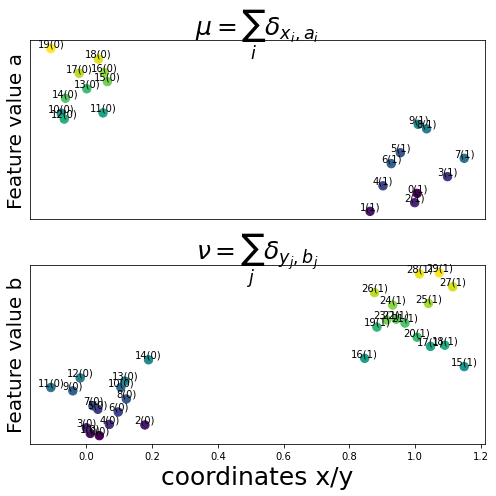

In [16]:
pl.figure(1, (7, 7))

# ---------------------
# Source: μ
# ---------------------
pl.subplot(2, 1, 1)
pl.scatter(ys, xs, c=phi, s=70)

# 각 점에 인덱스 + feature 값 표시
for i in range(n):
    label = f"{i}({int(ys[i, 0] > 0.5)})"   # 1 or 0로 단순화
    pl.text(
        ys[i, 0], xs[i, 0],
        label,
        fontsize=10,
        ha='center', va='bottom'
    )

pl.ylabel("Feature value a", fontsize=20)
pl.title("$\mu=\sum_i \delta_{x_i,a_i}$", fontsize=25, y=1)
pl.xticks(())
pl.yticks(())

# ---------------------
# Target: ν
# ---------------------
pl.subplot(2, 1, 2)
pl.scatter(yt, xt, c=phi2, s=70)

# 타겟 그래프도 인덱스 + feature 값 표시
for j in range(n2):
    label = f"{j}({int(yt[j, 0] > 0.5)})"   # 1 or 0로 단순화
    pl.text(
        yt[j, 0], xt[j, 0],
        label,
        fontsize=10,
        ha='center', va='bottom'
    )

pl.xlabel("coordinates x/y", fontsize=25)
pl.ylabel("Feature value b", fontsize=20)
pl.title("$\\nu=\sum_j \delta_{y_j,b_j}$", fontsize=25, y=1)
pl.yticks(())
pl.tight_layout()
pl.show()



In [64]:
C1 = ot.dist(xs)
C2 = ot.dist(xt)
M = ot.dist(ys, yt)
w1 = ot.unif(C1.shape[0])
w2 = ot.unif(C2.shape[0])
Got = ot.emd([], [], M)

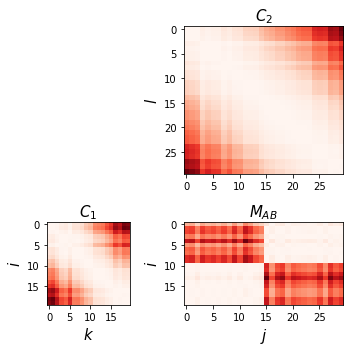

In [65]:
cmap = "Reds"

pl.figure(2, (5, 5))
fs = 15
l_x = [0, 5, 10, 15]
l_y = [0, 5, 10, 15, 20, 25]
gs = pl.GridSpec(5, 5)

ax1 = pl.subplot(gs[3:, :2])

pl.imshow(C1, cmap=cmap, interpolation="nearest")
pl.title("$C_1$", fontsize=fs)
pl.xlabel("$k$", fontsize=fs)
pl.ylabel("$i$", fontsize=fs)
pl.xticks(l_x)
pl.yticks(l_x)

ax2 = pl.subplot(gs[:3, 2:])

pl.imshow(C2, cmap=cmap, interpolation="nearest")
pl.title("$C_2$", fontsize=fs)
pl.ylabel("$l$", fontsize=fs)
pl.xticks(())
pl.yticks(l_y)
ax2.set_aspect("auto")

ax3 = pl.subplot(gs[3:, 2:], sharex=ax2, sharey=ax1)
pl.imshow(M, cmap=cmap, interpolation="nearest")
pl.yticks(l_x)
pl.xticks(l_y)
pl.ylabel("$i$", fontsize=fs)
pl.title("$M_{AB}$", fontsize=fs)
pl.xlabel("$j$", fontsize=fs)
pl.tight_layout()
ax3.set_aspect("auto")
pl.show()

In [96]:
alpha = 0.1

ot.tic()
Gwg, logw = fused_gromov_wasserstein(
    M, C1, C2, p, q, loss_fun="square_loss", alpha=alpha, verbose=True, log=True
)
ot.toc()

# reload_ext WGW
Gg, log = gromov_wasserstein(
    C1, C2, p, q, loss_fun="square_loss", verbose=True, log=True
)

It.  |Loss        |Relative loss|Absolute loss
------------------------------------------------
    0|4.684433e+03|0.000000e+00|0.000000e+00
    1|3.958951e+03|1.832511e-01|7.254820e+02
    2|2.183838e+03|8.128410e-01|1.775113e+03
    3|2.183838e+03|0.000000e+00|0.000000e+00
Elapsed time : 0.008280754089355469 s
It.  |Loss        |Relative loss|Absolute loss
------------------------------------------------
    0|4.683978e+04|0.000000e+00|0.000000e+00
    1|3.860061e+04|2.134468e-01|8.239175e+03
    2|2.182948e+04|7.682787e-01|1.677113e+04
    3|2.182948e+04|0.000000e+00|0.000000e+00


In [97]:
print("=== 1. Feature Cost (M) Scale ===")
print(f"Max : {M.max():.4f}")
print(f"Min : {M.min():.4f}")
print(f"Mean: {M.mean():.4f}")

print("\n=== 2. Structure Cost (C1, C2) Scale ===")
print(f"C1 (Source) Max : {C1.max():.4f}")
print(f"C2 (Target) Max : {C2.max():.4f}")
print(f"C1 Mean         : {C1.mean():.4f}")

print("\n=== 3. Scale Ratio (Structure / Feature) ===")
print(f"Ratio (C1 Max / M Max): {C1.max() / M.max():.4f}")

=== 1. Feature Cost (M) Scale ===
Max : 1.8142
Min : 0.0000
Mean: 0.5048

=== 2. Structure Cost (C1, C2) Scale ===
C1 (Source) Max : 286.0465
C2 (Target) Max : 906.0400
C1 Mean         : 59.9850

=== 3. Scale Ratio (Structure / Feature) ===
Ratio (C1 Max / M Max): 157.6750


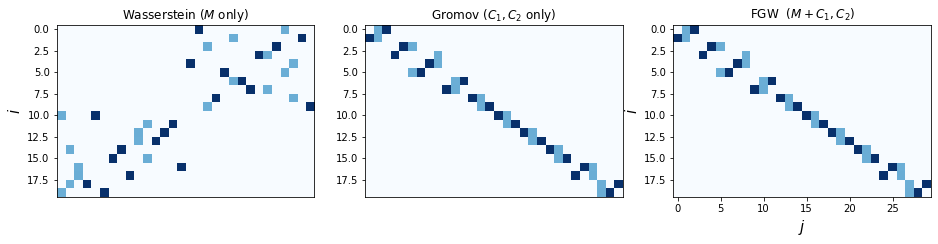

In [98]:
# visu OT matrix
cmap = "Blues"
fs = 15
pl.figure(3, (13, 5))
pl.clf()
pl.subplot(1, 3, 1)
pl.imshow(Got, cmap=cmap, interpolation="nearest")
pl.ylabel("$i$", fontsize=fs)
pl.xticks(())

pl.title("Wasserstein ($M$ only)")

pl.subplot(1, 3, 2)
pl.imshow(Gg, cmap=cmap, interpolation="nearest")
pl.title("Gromov ($C_1,C_2$ only)")
pl.xticks(())
pl.subplot(1, 3, 3)
pl.imshow(Gwg, cmap=cmap, interpolation="nearest")
pl.title("FGW  ($M+C_1,C_2$)")

pl.xlabel("$j$", fontsize=fs)
pl.ylabel("$i$", fontsize=fs)

pl.tight_layout()
pl.show()

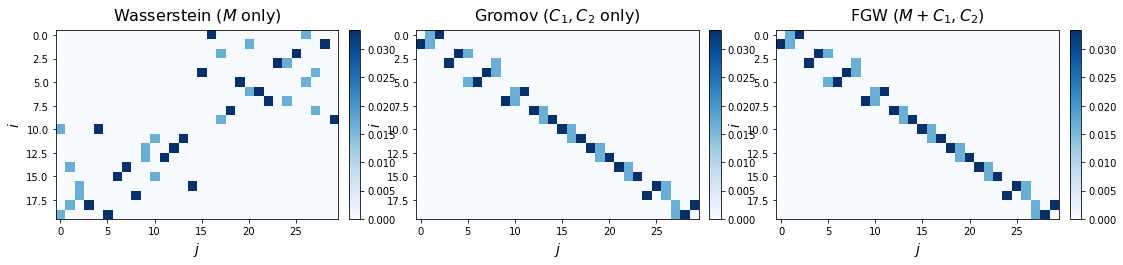

In [99]:
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
import numpy as np

def plot_plan(ax, matrix, title):
    im = ax.imshow(matrix, cmap="Blues", interpolation="nearest")
    ax.set_title(title, fontsize=16, pad=10)
    ax.set_xlabel("$j$", fontsize=14)
    ax.set_ylabel("$i$", fontsize=14)

    # --- Colorbar aligned cleanly ---
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="4%", pad=0.15)
    cb = plt.colorbar(im, cax=cax)
    cb.ax.tick_params(labelsize=10)

    return ax


# --- Main figure layout ---
fig, axes = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)

plot_plan(axes[0], Got, "Wasserstein ($M$ only)")
plot_plan(axes[1], Gg, "Gromov ($C_1, C_2$ only)")
plot_plan(axes[2], Gwg, "FGW ($M + C_1, C_2$)")

plt.show()


In [100]:
# --- 4. Graph Matching 시각화 함수 (NumPy 전용) ---
def plot_graph_matching_numpy(xs, ys, xt, yt, Pi, title="Graph Matching"):
    # 차원 축소 (N, 1) -> (N,)
    xs = xs.squeeze()
    ys = ys.squeeze()
    xt = xt.squeeze()
    yt = yt.squeeze()
    pi = Pi # 이미 numpy

    # Target 그래프를 오른쪽으로 이동시켜서 그리기
    x_shift = xs.max() - xt.min() + 5.0 
    xt_shifted = xt + x_shift

    plt.figure(figsize=(14, 6))
    ax = plt.gca()

    # [1] 연결선 그리기 (매칭된 노드끼리)
    threshold = 1e-4 # 플랜 값이 이보다 큰 경우만 선을 그림
    indices = np.argwhere(pi > threshold)
    
    lines = []
    colors = []
    linewidths = []

    # Plan의 최대값을 기준으로 선의 진하기/굵기 결정
    pi_max = pi.max()

    for i, j in indices:
        p1 = (xs[i], ys[i])
        p2 = (xt_shifted[j], yt[j])
        lines.append([p1, p2])
        
        strength = pi[i, j] / pi_max
        # 매칭이 강할수록 진한 회색/검정색
        colors.append((0.2, 0.2, 0.2, strength * 0.6)) 
        linewidths.append(strength * 2.0)

    lc = mc.LineCollection(lines, colors=colors, linewidths=linewidths, zorder=1)
    ax.add_collection(lc)

    # [2] 노드 그리기 (Feature 값인 ys, yt로 색상 표현)
    # 스케일을 맞추기 위해 vmin, vmax 통일
    vmin = min(ys.min(), yt.min())
    vmax = max(ys.max(), yt.max())
    
    sc1 = plt.scatter(xs, ys, c=ys, cmap='coolwarm', vmin=vmin, vmax=vmax, s=150, edgecolors='k', zorder=2, label='Source')
    sc2 = plt.scatter(xt_shifted, yt, c=yt, cmap='coolwarm', vmin=vmin, vmax=vmax, s=150, edgecolors='k', marker='D', zorder=2, label='Target')

    # [3] 인덱스 텍스트 추가
    for i in range(len(xs)):
        ax.text(xs[i], ys[i]+0.05, str(i), fontsize=9, ha='center', fontweight='bold')
    for i in range(len(xt)):
        ax.text(xt_shifted[i], yt[i]+0.05, str(i), fontsize=9, ha='center', fontweight='bold')

    # 타이틀 및 범위 설정
    plt.title(title, fontsize=18, pad=20)
    plt.axis('off') # 축 숨기기
    
    # 범례 및 설명
    plt.text(xs.mean(), ys.min() - 0.5, "Source Graph\n(Left: Red -> Blue)", ha='center', fontsize=12)
    plt.text(xt_shifted.mean(), yt.min() - 0.5, "Target Graph\n(Right: Blue -> Red)", ha='center', fontsize=12)
    
    cbar = plt.colorbar(sc1, label="Feature Value (Color)", shrink=0.7)
    plt.tight_layout()
    plt.show()

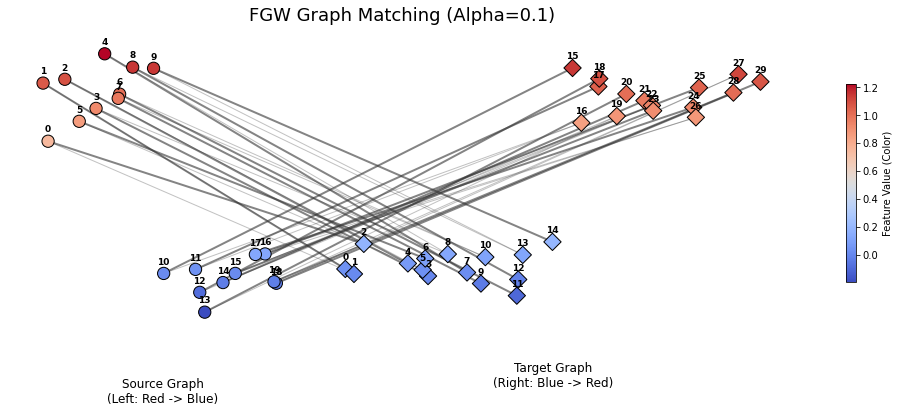

In [101]:
plot_graph_matching_numpy(xs, ys, xt, yt, Gwg, title=f"FGW Graph Matching (Alpha={alpha})")

### High Dimensional 일 때에는 어떻게 될까? 

- 당연히 feature vector가 고차원이 되는 만큼 alpha를 암만 키워도 Wasserstein에 가까운 결과로 이어지게 될 전망 


Max value in Structure Matrix C1: 292.10
Max value in Feature Matrix M:    24004.47
Scale Ratio (M / C1):             82.18


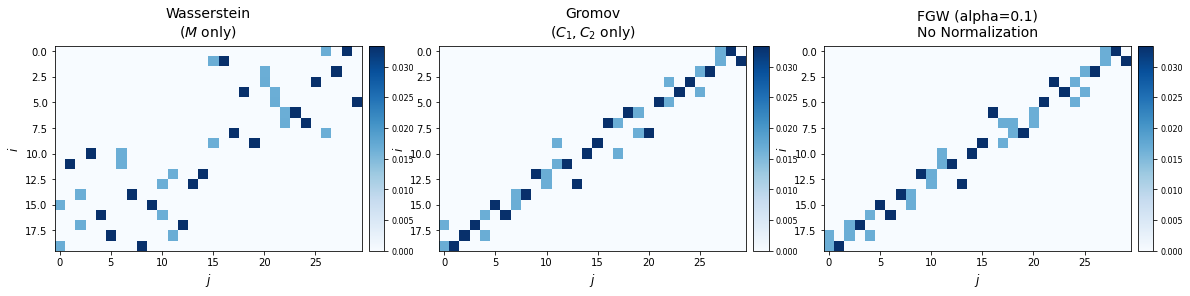

In [159]:
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
import numpy as np
import ot
from ot.gromov import gromov_wasserstein, fused_gromov_wasserstein

# -----------------------------------------------------------------------------
# 1. Data Generation
# -----------------------------------------------------------------------------
np.random.seed(42)

n = 20
n2 = 30
dim = 768  # 고차원 Feature

# Structure (Small Scale)
# 1D 상의 위치, 거리는 기껏해야 0 ~ 20 정도
sig = 1
phi = np.arange(n)[:, None]
xs = phi + sig * np.random.randn(n, 1)

phi2 = np.arange(n2)[:, None]
xt = phi2 + sig * np.random.randn(n2, 1)

# Feature (Large Scale due to dimensionality)
# 768차원의 유클리드 거리는 차원이 클수록 값이 커집니다 (Distance Concentration)
base_signal_1 = np.random.randn(1, dim)
base_signal_2 = np.random.randn(1, dim) + 5

ys = np.vstack((
    base_signal_1 + np.random.randn(n // 2, dim), 
    base_signal_2 + np.random.randn(n // 2, dim)
))

yt_raw = np.vstack((
    base_signal_1 + np.random.randn(n2 // 2, dim),
    base_signal_2 + np.random.randn(n2 // 2, dim)
))
yt = yt_raw[::-1, :] # Feature 순서 반전 (Anti-diagonal 유도)

p = ot.unif(n)
q = ot.unif(n2)

# -----------------------------------------------------------------------------
# 2. Compute Matrices (NO Normalization)
# -----------------------------------------------------------------------------
C1 = ot.dist(xs)
C2 = ot.dist(xt)
M = ot.dist(ys, yt)

# [확인용] 스케일 차이 출력
print(f"Max value in Structure Matrix C1: {C1.max():.2f}")
print(f"Max value in Feature Matrix M:    {M.max():.2f}")
print(f"Scale Ratio (M / C1):             {M.max() / C1.max():.2f}")

# -----------------------------------------------------------------------------
# 3. Compute Plans
# -----------------------------------------------------------------------------
# 3-1. Wasserstein
Got = ot.emd(p, q, M)

# 3-2. Gromov-Wasserstein
Gg = gromov_wasserstein(C1, C2, p, q, loss_fun="square_loss", verbose=False)

# 3-3. Fused Gromov-Wasserstein (Extreme Alpha)
# alpha = 0.99로 설정하여 "구조(Structure)"에 99% 가중치를 줍니다.
# 하지만 정규화를 안 했으므로 M의 스케일이 이를 압도할 것입니다.
alpha = 0.1
Gwg = fused_gromov_wasserstein(M, C1, C2, p, q, loss_fun="square_loss", alpha=alpha, verbose=False)

# -----------------------------------------------------------------------------
# 4. Visualization
# -----------------------------------------------------------------------------
def plot_plan(ax, matrix, title):
    im = ax.imshow(matrix, cmap="Blues", interpolation="nearest")
    ax.set_title(title, fontsize=14, pad=10)
    ax.set_xlabel("$j$", fontsize=12)
    ax.set_ylabel("$i$", fontsize=12)
    
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="5%", pad=0.1)
    cb = plt.colorbar(im, cax=cax)
    cb.ax.tick_params(labelsize=8)

fig, axes = plt.subplots(1, 3, figsize=(16, 5), constrained_layout=True)

plot_plan(axes[0], Got, "Wasserstein\n($M$ only)")
plot_plan(axes[1], Gg, "Gromov\n($C_1, C_2$ only)")
# Title에 실험 조건 명시
plot_plan(axes[2], Gwg, f"FGW (alpha={alpha})\nNo Normalization")

plt.show()

In [23]:
# 실제 GW Loss 항의 최대값 계산
# C1의 최대값과 C2의 최소값(혹은 그 반대)의 차이의 제곱이 최대 비용이 됩니다.
gw_cost_max = (C1.max() - C2.min()) ** 2

print(f"1. Feature Cost (M) Max:      {M.max():,.2f}")
print(f"2. Structure Cost (GW) Max:   {gw_cost_max:,.2f} (Internal Term)")
print(f"3. Actual Ratio (GW / M):     {gw_cost_max / M.max():.2f}")

1. Feature Cost (M) Max:      1.00
2. Structure Cost (GW) Max:   1.00 (Internal Term)
3. Actual Ratio (GW / M):     1.00


Max value in Structure Matrix C1 (Cosine, Normed): 0.0000
Max value in Feature Matrix M (SqEuclidean):       24004.4701
Scale Ratio (M / C1):                              24004470140698.81


/home/eungyeop/anaconda3/envs/project/lib/python3.8/site-packages/ot/optim.py:291: RuntimeWarning: invalid value encountered in scalar divide
  relative_delta_cost_G = abs_delta_cost_G / abs(cost_G)


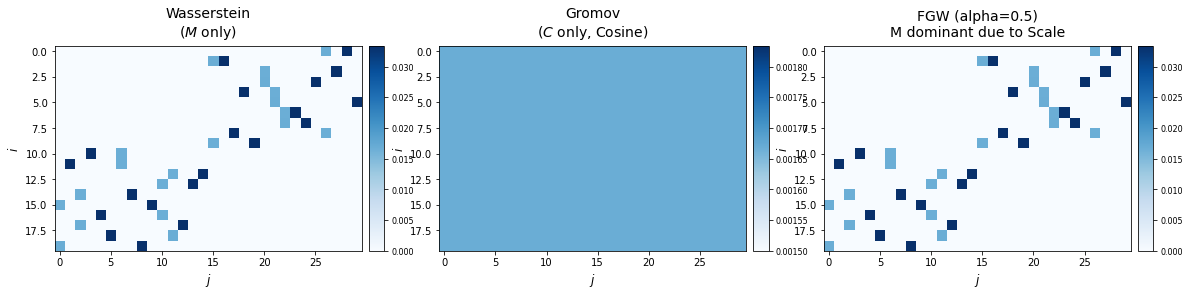

In [164]:
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
import numpy as np
import ot
from ot.gromov import gromov_wasserstein, fused_gromov_wasserstein
from scipy.spatial.distance import cdist # Cosine distance 계산을 위해 추가

# -----------------------------------------------------------------------------
# 1. Data Generation
# -----------------------------------------------------------------------------
np.random.seed(42)

n = 20
n2 = 30
dim = 768  # 고차원 Feature

# Structure (xs, xt)
sig = 1
phi = np.arange(n)[:, None]
xs = phi + sig * np.random.randn(n, 1)

phi2 = np.arange(n2)[:, None]
xt = phi2 + sig * np.random.randn(n2, 1)

# Feature (ys, yt) - 768 Dimension
base_signal_1 = np.random.randn(1, dim)
base_signal_2 = np.random.randn(1, dim) + 5

ys = np.vstack((
    base_signal_1 + np.random.randn(n // 2, dim), 
    base_signal_2 + np.random.randn(n // 2, dim)
))

yt_raw = np.vstack((
    base_signal_1 + np.random.randn(n2 // 2, dim),
    base_signal_2 + np.random.randn(n2 // 2, dim)
))
yt = yt_raw[::-1, :] # 순서 반전

p = ot.unif(n)
q = ot.unif(n2)

# -----------------------------------------------------------------------------
# 2. Compute Matrices (Modified)
# -----------------------------------------------------------------------------

# [변경 1] Structure Cost: Cosine Distance (1 - Cosine Similarity)
# 주의: 1D 데이터에서 Cosine은 방향(부호)만 보므로 거의 0에 가깝게 나올 수 있지만,
# 사용자의 의도대로 "작은 스케일"을 만들기 위해 그대로 진행합니다.
C1 = cdist(xs, xs, metric='cosine')
C2 = cdist(xt, xt, metric='cosine')

# [변경 2] Structure Normalization (0~1 사이로 재보정)
# NaN 방지 (0으로 나누는 경우 대비)
if C1.max() > 0: C1 /= C1.max()
if C2.max() > 0: C2 /= C2.max()

# [변경 3] Feature Cost: Squared Euclidean (그대로 유지 -> 값 매우 큼)
M = ot.dist(ys, yt, metric='sqeuclidean') 

# [확인용] 스케일 비교
print(f"Max value in Structure Matrix C1 (Cosine, Normed): {C1.max():.4f}")
print(f"Max value in Feature Matrix M (SqEuclidean):       {M.max():.4f}")
print(f"Scale Ratio (M / C1):                              {M.max() / (C1.max() + 1e-9):.2f}")

# -----------------------------------------------------------------------------
# 3. Compute Plans
# -----------------------------------------------------------------------------
# 3-1. Wasserstein (Feature Only)
Got = ot.emd(p, q, M)

# 3-2. Gromov-Wasserstein (Structure Only)
Gg = gromov_wasserstein(C1, C2, p, q, loss_fun="square_loss", verbose=False)

# 3-3. Fused Gromov-Wasserstein
# alpha를 0.5 (반반)로 주더라도 M이 너무 커서 구조가 무시되는지 확인
alpha = 0.5
Gwg = fused_gromov_wasserstein(M, C1, C2, p, q, loss_fun="square_loss", alpha=alpha, verbose=False)

# -----------------------------------------------------------------------------
# 4. Visualization
# -----------------------------------------------------------------------------
def plot_plan(ax, matrix, title):
    im = ax.imshow(matrix, cmap="Blues", interpolation="nearest")
    ax.set_title(title, fontsize=14, pad=10)
    ax.set_xlabel("$j$", fontsize=12)
    ax.set_ylabel("$i$", fontsize=12)
    
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="5%", pad=0.1)
    cb = plt.colorbar(im, cax=cax)
    cb.ax.tick_params(labelsize=8)

fig, axes = plt.subplots(1, 3, figsize=(16, 5), constrained_layout=True)

plot_plan(axes[0], Got, "Wasserstein\n($M$ only)")
plot_plan(axes[1], Gg, "Gromov\n($C$ only, Cosine)")
plot_plan(axes[2], Gwg, f"FGW (alpha={alpha})\nM dominant due to Scale")

plt.show()

Max value in Structure Matrix C1 (Cosine of y): 1.0527
Max value in Feature Matrix M (SqEuclidean of y): 24245.1231
Scale Ratio (M / C1): 23032.11


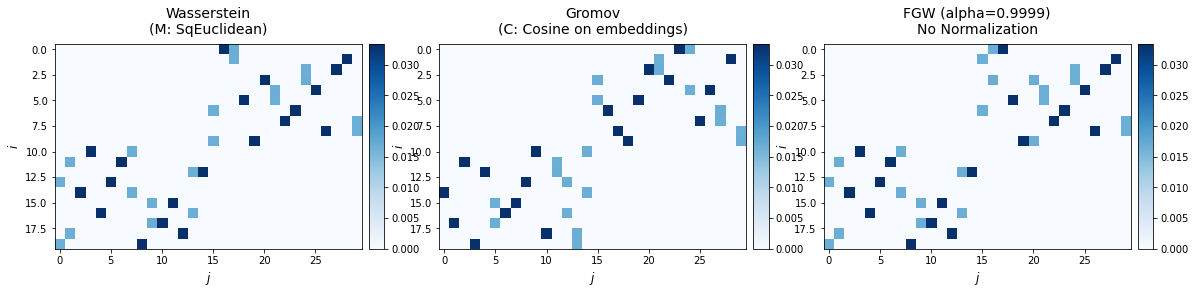


   [정량적 비교] 행렬 간 차이 (Frobenius Norm)
   * 값이 0에 가까울수록 두 Plan이 동일함을 의미
1. Distance (FGW vs Wasserstein): 0.047140
2. Distance (FGW vs Gromov):      0.228522
3. Reference (Wasserstein vs Gromov): 0.229734
--------------------------------------------------
결론: FGW는 Wasserstein 결과에 4.8배 더 가깝습니다.
      -> Feature Scale이 Structure를 압도하고 있습니다.


In [17]:
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
import numpy as np
import ot
from ot.gromov import gromov_wasserstein, fused_gromov_wasserstein
from scipy.spatial.distance import cdist

# -----------------------------------------------------------------------------
# 1. Data Generation (Same as before)
# -----------------------------------------------------------------------------
np.random.seed(42)

n = 20
n2 = 30
dim = 768 

# (xs, xt는 이제 구조 계산에 안 씁니다)
base_signal_1 = np.random.randn(1, dim)
base_signal_2 = np.random.randn(1, dim) + 5

ys = np.vstack((
    base_signal_1 + np.random.randn(n // 2, dim), 
    base_signal_2 + np.random.randn(n // 2, dim)
))

yt_raw = np.vstack((
    base_signal_1 + np.random.randn(n2 // 2, dim),
    base_signal_2 + np.random.randn(n2 // 2, dim)
))
yt = yt_raw[::-1, :] # 순서 반전

p = ot.unif(n)
q = ot.unif(n2)

# -----------------------------------------------------------------------------
# 2. Compute Matrices (User's Intent)
# -----------------------------------------------------------------------------

# [핵심 변경] Structure를 "Feature(y) 간의 Cosine 거리"로 정의
# cdist(metric='cosine')은 1 - CosineSimilarity 값을 반환합니다.
# 범위: 0(완전 일치) ~ 2(완전 반대)
C1 = cdist(ys, ys, metric='cosine')
C2 = cdist(yt, yt, metric='cosine')

# [비교 대상] Feature Cost는 그대로 Squared Euclidean (값 큼)
M = ot.dist(ys, yt, metric='sqeuclidean')

# 정규화 없이(NO Normalization) 스케일 비교
print(f"Max value in Structure Matrix C1 (Cosine of y): {C1.max():.4f}")
print(f"Max value in Feature Matrix M (SqEuclidean of y): {M.max():.4f}")
print(f"Scale Ratio (M / C1): {M.max() / C1.max():.2f}")

# -----------------------------------------------------------------------------
# 3. Compute Plans
# -----------------------------------------------------------------------------
# 3-1. Wasserstein (M only)
Got = ot.emd(p, q, M)

# 3-2. Gromov (C only) - 이제 C도 y로 만들었으니 의미가 있습니다!
Gg = gromov_wasserstein(C1, C2, p, q, loss_fun="square_loss", verbose=False)

# 3-3. FGW (Both) - alpha=0.5
alpha = 0.9999
Gwg = fused_gromov_wasserstein(M, C1, C2, p, q, loss_fun="square_loss", alpha=alpha, verbose=False)

# -----------------------------------------------------------------------------
# 4. Visualization
# -----------------------------------------------------------------------------
def plot_plan(ax, matrix, title):
    im = ax.imshow(matrix, cmap="Blues", interpolation="nearest")
    ax.set_title(title, fontsize=14, pad=10)
    ax.set_xlabel("$j$", fontsize=12)
    ax.set_ylabel("$i$", fontsize=12)
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="5%", pad=0.1)
    cb = plt.colorbar(im, cax=cax)

fig, axes = plt.subplots(1, 3, figsize=(16, 5), constrained_layout=True)

plot_plan(axes[0], Got, "Wasserstein\n(M: SqEuclidean)")
plot_plan(axes[1], Gg, "Gromov\n(C: Cosine on embeddings)")
plot_plan(axes[2], Gwg, f"FGW (alpha={alpha})\nNo Normalization")

plt.show()


# -----------------------------------------------------------------------------
# 5. Quantitative Comparison (Matrix Differences)
# -----------------------------------------------------------------------------
print("\n" + "="*50)
print("   [정량적 비교] 행렬 간 차이 (Frobenius Norm)")
print("   * 값이 0에 가까울수록 두 Plan이 동일함을 의미")
print("="*50)

# Difference calculation
diff_W_FGW = np.linalg.norm(Gwg - Got) # FGW와 Wasserstein의 차이
diff_G_FGW = np.linalg.norm(Gwg - Gg)  # FGW와 Gromov의 차이
diff_W_G   = np.linalg.norm(Got - Gg)  # Wasserstein과 Gromov 자체의 차이 (기준점)

print(f"1. Distance (FGW vs Wasserstein): {diff_W_FGW:.6f}")
print(f"2. Distance (FGW vs Gromov):      {diff_G_FGW:.6f}")
print(f"3. Reference (Wasserstein vs Gromov): {diff_W_G:.6f}")

print("-" * 50)
# 해석
if diff_W_FGW < diff_G_FGW:
    ratio = diff_G_FGW / (diff_W_FGW + 1e-9)
    print(f"결론: FGW는 Wasserstein 결과에 {ratio:.1f}배 더 가깝습니다.")
    print("      -> Feature Scale이 Structure를 압도하고 있습니다.")
else:
    ratio = diff_W_FGW / (diff_G_FGW + 1e-9)
    print(f"결론: FGW는 Gromov 결과에 {ratio:.1f}배 더 가깝습니다.")
    print("      -> Structure 정보가 반영되고 있습니다.")

Start Training (UMAP Trajectory Enabled)...
--------------------------------------------------
Epoch    0 | FGW Loss: 0.434793
   [RAW COST SCALE COMPARISON]
   1. Feature Cost (M) Max:      9.16
   2. Structure Cost (GW) Max:   0.03 (Internal Term)
   3. Actual Ratio (GW / M):     0.00
--------------------------------------------------
Epoch  100 | FGW Loss: 0.195895
   [RAW COST SCALE COMPARISON]
   1. Feature Cost (M) Max:      17.80
   2. Structure Cost (GW) Max:   2.64 (Internal Term)
   3. Actual Ratio (GW / M):     0.15
--------------------------------------------------
Epoch  200 | FGW Loss: 0.145752
   [RAW COST SCALE COMPARISON]
   1. Feature Cost (M) Max:      21.93
   2. Structure Cost (GW) Max:   8.77 (Internal Term)
   3. Actual Ratio (GW / M):     0.40
--------------------------------------------------
Epoch  300 | FGW Loss: 0.121455
   [RAW COST SCALE COMPARISON]
   1. Feature Cost (M) Max:      24.89
   2. Structure Cost (GW) Max:   17.18 (Internal Term)
   3. Actual R

/home/eungyeop/anaconda3/envs/featllm/lib/python3.8/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


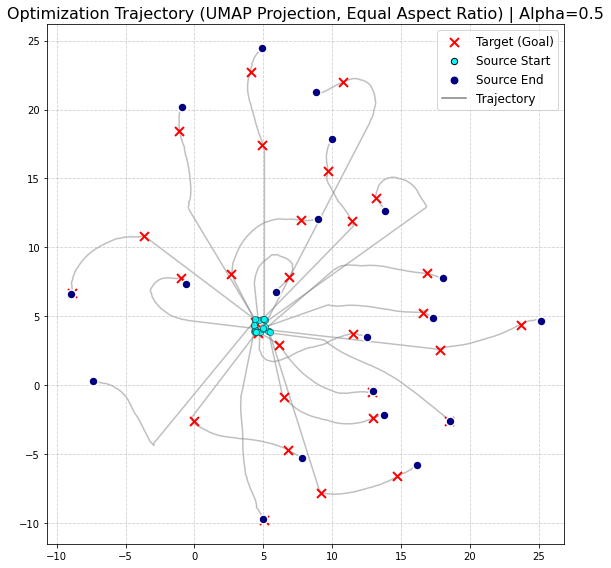

In [45]:
import torch
import torch.optim as optim
import ot
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE 
# UMAP 라이브러리가 설치되어 있어야 합니다 (pip install umap-learn)
# UMAP 모듈 임포트 시도를 try/except로 감싸 안정성을 확보합니다.
try:
    import umap.umap_ as umap
    UMAP_AVAILABLE = True
except ImportError:
    try:
        import umap
        UMAP_AVAILABLE = True
    except ImportError:
        print("UMAP not found. Falling back to PCA for visualization.")
        UMAP_AVAILABLE = False


# -----------------------------------------------------------------------------
# 1. Setup Data
# -----------------------------------------------------------------------------
torch.manual_seed(42)
np.random.seed(42)

n_source = 20
n_target = 30
dim = 768
EPSILON = 1e-9 # 0으로 나누는 것을 방지하기 위한 작은 값

# [Target Data]: Target 클러스터를 중앙에 모아 UMAP이 더 잘 분리하도록 유도
target_emb = torch.randn(n_target, dim) * 0.1 
# target_emb[:n_target//2] += 2.0 # Cluster 1: +2.0
# target_emb[n_target//2:] -= 2.0 # Cluster 2: -2.0

# Source Data (Learnable): Target과 겹쳐서 시작
source_emb = torch.randn(n_source, dim, requires_grad=True)

# 초기화 연산을 .data를 이용해 수행하여 Leaf 상태를 유지합니다.
with torch.no_grad():
    source_emb.data *= 0.01 # 시작 분산을 극도로 작게 (거의 한 점)

# Distribution weights
p = ot.unif(n_source, type_as=source_emb)
q = ot.unif(n_target, type_as=target_emb)

# -----------------------------------------------------------------------------
# 2. Training Loop (Robust Normalization)
# -----------------------------------------------------------------------------
optimizer = optim.SGD([source_emb], lr=0.5) 

print("Start Training (UMAP Trajectory Enabled)...")
loss_history = []
source_history = [] 
alpha = 0.5 

# 초기 상태
source_history.append(source_emb.detach().cpu().numpy().copy())

# [핵심 수정] 최종 수렴 확인을 위해 5000 Epoch으로 늘림
n_epochs = 5000
for epoch in range(n_epochs):
    optimizer.zero_grad()
    
    # --- Matrix Computation ---
    M_raw = ot.dist(source_emb, target_emb)
    C1_raw = ot.dist(source_emb, source_emb)
    C2_raw = ot.dist(target_emb, target_emb)
    
    # Robust Max Normalization (NaN 방지)
    M = M_raw / (M_raw.max() + EPSILON) 
    C1 = C1_raw / (C1_raw.max() + EPSILON)
    C2 = C2_raw / (C2_raw.max() + EPSILON)
    
    # --- FGW Loss ---
    fgw_loss = ot.gromov.fused_gromov_wasserstein2(
        M, C1, C2, p, q,
        loss_fun='square_loss', alpha=alpha
    )
    
    if torch.isnan(fgw_loss):
        print("Loss is NaN! Stopping training.")
        break

    # --- Update ---
    fgw_loss.backward()
    optimizer.step()
    
    loss_history.append(fgw_loss.item())
    
    # [로그 출력]
    if epoch % 100 == 0:
        raw_m_max = M_raw.max().item()
        gw_max_cost = (C1_raw.max().item() - C2_raw.min().item())**2
        actual_ratio = gw_max_cost / (raw_m_max + EPSILON)
        
        print("-" * 50)
        print(f"Epoch {epoch:4d} | FGW Loss: {fgw_loss.item():.6f}")
        print("   [RAW COST SCALE COMPARISON]")
        print(f"   1. Feature Cost (M) Max:      {raw_m_max:,.2f}")
        print(f"   2. Structure Cost (GW) Max:   {gw_max_cost:,.2f} (Internal Term)")
        print(f"   3. Actual Ratio (GW / M):     {actual_ratio:,.2f}")
        # 매 스텝 저장
        source_history.append(source_emb.detach().cpu().numpy().copy())

# 최종 상태
source_history.append(source_emb.detach().cpu().numpy().copy())
print("-" * 50)
print(f"Training finished. Final Loss: {loss_history[-1]:.6f}")


# -----------------------------------------------------------------------------
# 3. Visualization: Trajectories (UMAP 2D Projection - ALL DATA)
# -----------------------------------------------------------------------------
print("Visualizing Trajectories with UMAP (Optimized Scaling)...")
projection_method = "UMAP"

# [핵심 수정] 모든 시점의 Source와 Target을 합쳐서 UMAP을 단 1회 수행합니다.
# 이렇게 해야 모든 궤적이 하나의 일관된 좌표계를 가집니다.
all_data = np.vstack(source_history + [target_emb.numpy()])

if UMAP_AVAILABLE:
    # UMAP 변환기 (두 클러스터가 합쳐진 것을 보여줄 것입니다)
    reducer = umap.UMAP(n_neighbors=5, min_dist=0.3, n_components=2, random_state=42)
    data_2d = reducer.fit_transform(all_data)
else:
    # UMAP이 실패하면 PCA로 대체 (이전의 안정적인 fallback)
    pca = PCA(n_components=2)
    data_2d = pca.fit_transform(all_data)
    projection_method = "PCA"

# 데이터 분리
target_2d = data_2d[-n_target:]
source_2d_history = []
start_idx = 0
n_snapshots = len(source_history)
for _ in range(n_snapshots):
    end_idx = start_idx + n_source
    source_2d_history.append(data_2d[start_idx:end_idx])
    start_idx = end_idx

source_2d_history = np.array(source_2d_history) 

# 그래프 그리기
plt.figure(figsize=(12, 8))
ax = plt.gca() # 현재 축을 가져옵니다.

# 1. Target (Goal) - 빨간색 X
plt.scatter(target_2d[:, 0], target_2d[:, 1], c='red', marker='x', s=80, linewidths=2, label='Target (Goal)', zorder=2)

# 2. Source Trajectories
for i in range(n_source):
    traj = source_2d_history[:, i, :]
    
    # 이동 경로 선 (진한 회색)
    plt.plot(traj[:, 0], traj[:, 1], color='gray', alpha=0.5, linewidth=1.5, zorder=1)
    
    # 시작점 (하늘색)
    plt.scatter(traj[0, 0], traj[0, 1], color='cyan', s=40, alpha=0.8, edgecolors='black', linewidth=0.5, zorder=3)
    
    # 끝점 (진한 파랑)
    plt.scatter(traj[-1, 0], traj[-1, 1], color='navy', s=80, edgecolors='white', linewidth=1.5, zorder=4)

# [핵심 수정] UMAP 시각화에서는 축 비율을 1:1로 강제합니다.
ax.set_aspect('equal', adjustable='box') 

# Legend (가짜 핸들 생성)
plt.scatter([], [], c='cyan', s=40, edgecolors='black', label='Source Start')
plt.scatter([], [], c='navy', s=80, edgecolors='white', label='Source End')
plt.plot([], [], color='gray', linewidth=1.5, label='Trajectory')

plt.title(f"Optimization Trajectory ({projection_method} Projection, Equal Aspect Ratio) | Alpha={alpha}", fontsize=16)
plt.legend(loc='upper right', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [ ]:
import torch
import torch.optim as optim
import ot
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA
# UMAP 라이브러리가 설치되어 있어야 합니다 (pip install umap-learn)
# UMAP 모듈 임포트 시도를 try/except로 감싸 안정성을 확보합니다.
try:
    import umap.umap_ as umap
    UMAP_AVAILABLE = True
except ImportError:
    try:
        import umap
        UMAP_AVAILABLE = True
    except ImportError:
        print("UMAP not found. Falling back to PCA for visualization.")
        UMAP_AVAILABLE = False
# -----------------------------------------------------------------------------
# 1. Setup Data
# -----------------------------------------------------------------------------
torch.manual_seed(42)
np.random.seed(42)
n_source = 20
n_target = 30
dim = 768
EPSILON = 1e-9 # 0으로 나누는 것을 방지하기 위한 작은 값

# [Target Data]: Target 클러스터 내부 분산을 10배 키워서 (0.1 -> 1.0) UMAP이 퍼뜨리도록 유도
target_emb = torch.randn(n_target, dim) * 1.0 # 분산 증대 (이전 0.1)
# target_emb[:n_target//2] += 2.0 # Cluster 1: +2.0
# target_emb[n_target//2:] -= 2.0 # Cluster 2: -2.0

# Source Data (Learnable): Target과 겹쳐서 시작

source_emb = torch.randn(n_source, dim, requires_grad=True)

# 초기화 연산을 .data를 이용해 수행하여 Leaf 상태를 유지합니다.
with torch.no_grad():

    source_emb.data *= 0.01 # 시작 분산을 극도로 작게 (거의 한 점)

# Distribution weights
p = ot.unif(n_source, type_as=source_emb)
q = ot.unif(n_target, type_as=target_emb)
# -----------------------------------------------------------------------------
# 2. Training Loop (Robust Normalization)
# -----------------------------------------------------------------------------
optimizer = optim.SGD([source_emb], lr=0.5)

print("Start Training (UMAP Trajectory Enabled - Increased Target Variance)...")

loss_history = []
feat_cost_history, struc_cost_history, source_history = [], [] , [] 
snapshot_epochs = [0, 100, 200, 300, 400, 1000, 4999]
plan_snapshots = {}
alpha = 0.5

# 초기 상태
source_history = [source_emb.detach().cpu().numpy().copy()]

# [핵심 수정] 최종 수렴 확인을 위해 5000 Epoch으로 늘림

n_epochs = 5000
for epoch in range(n_epochs):
    optimizer.zero_grad()
    # --- Matrix Computation ---
    M_raw = ot.dist(source_emb, target_emb)
    C1_raw = ot.dist(source_emb, source_emb)
    C2_raw = ot.dist(target_emb, target_emb)

    # Robust Max Normalization (NaN 방지)
    M = M_raw / (M_raw.max() + EPSILON)
    C1 = C1_raw / (C1_raw.max() + EPSILON)
    C2 = C2_raw / (C2_raw.max() + EPSILON)
    # --- FGW Loss ---
    fgw_loss = ot.gromov.fused_gromov_wasserstein2(
        M, C1, C2, p, q,
        loss_fun='square_loss', alpha=alpha
    )

    if torch.isnan(fgw_loss):
        print("Loss is NaN! Stopping training.")
        break
    # --- [분석] Transport Plan (T) 및 Cost 계산 (라이브러리 함수 사용) ---
    with torch.no_grad():
        # 1. Transport Plan T 계산
        T = ot.gromov.fused_gromov_wasserstein(
            M, C1, C2, p, q, loss_fun='square_loss', alpha=alpha
        )
        
        # 2. Feature Cost 계산: <M, T>
        current_feat_cost = torch.sum(M * T).item()
        
        # 3. Structure Cost 계산 (문서 참조 방식)
        # gwloss에 들어갈 constC, hC1, hC2를 init_matrix로 생성합니다.
        constC, hC1, hC2 = ot.gromov.init_matrix(
            C1, C2, p, q, loss_fun='square_loss'
        )
        
        # 이제 gwloss를 호출합니다 (인자 4개: constC, hC1, hC2, T)
        current_struc_cost_tensor = ot.gromov.gwloss(constC, hC1, hC2, T)
        current_struc_cost = current_struc_cost_tensor.item()
        
        # 기록
        loss_history.append(fgw_loss.item())
        feat_cost_history.append(current_feat_cost)
        struc_cost_history.append(current_struc_cost)
        
        # 스냅샷 저장
        if epoch in snapshot_epochs:
            plan_snapshots[epoch] = T.cpu().numpy()
    # --- Update ---
    fgw_loss.backward()
    optimizer.step()
    loss_history.append(fgw_loss.item())

    # [로그 출력]
    if epoch % 100 == 0:
        raw_m_max = M_raw.max().item()
        gw_max_cost = (C1_raw.max().item() - C2_raw.min().item())**2
        actual_ratio = gw_cost_max / (raw_m_max + EPSILON)

        print("-" * 50)
        print(f"Epoch {epoch:4d} | FGW Loss: {fgw_loss.item():.6f}")
        print("   [RAW COST SCALE COMPARISON]")
        print(f"   1. Feature Cost (M) Max:      {raw_m_max:,.2f}")
        print(f"   2. Structure Cost (GW) Max:   {gw_max_cost:,.2f} (Internal Term)")
        print(f"   3. Actual Ratio (GW / M):     {actual_ratio:,.2f}")
        # 매 스텝 저장
        source_history.append(source_emb.detach().cpu().numpy().copy())
# 최종 상태
source_history.append(source_emb.detach().cpu().numpy().copy())
print("-" * 50)
print(f"Training finished. Final Loss: {loss_history[-1]:.6f}")
# -----------------------------------------------------------------------------
# 3. Visualization: Trajectories (UMAP 2D Projection - ALL DATA)
# -----------------------------------------------------------------------------
print("Visualizing Trajectories with UMAP (Optimized Scaling)...")
projection_method = "UMAP"

# [핵심 수정] 모든 시점의 Source와 Target을 합쳐서 UMAP을 단 1회 수행합니다.
all_data = np.vstack(source_history + [target_emb.numpy()])

if UMAP_AVAILABLE:
    # UMAP 변환기 (두 클러스터가 합쳐진 것을 보여줄 것입니다)
    reducer = umap.UMAP(n_neighbors=5, min_dist=0.3, n_components=2, random_state=42)
    data_2d = reducer.fit_transform(all_data)

else:
    # UMAP이 실패하면 PCA로 대체 (이전의 안정적인 fallback)
    pca = PCA(n_components=2)
    data_2d = pca.fit_transform(all_data)
    projection_method = "PCA"
# 데이터 분리
target_2d = data_2d[-n_target:]
source_2d_history = []
start_idx = 0
n_snapshots = len(source_history)

for _ in range(n_snapshots):
    end_idx = start_idx + n_source
    source_2d_history.append(data_2d[start_idx:end_idx])
    start_idx = end_idx
source_2d_history = np.array(source_2d_history)

# 그래프 그리기
plt.figure(figsize=(12, 8))
ax = plt.gca() # 현재 축을 가져옵니다.

# 1. Target (Goal) - 빨간색 X

plt.scatter(target_2d[:, 0], target_2d[:, 1], c='red', marker='x', s=80, linewidths=2, label='Target (Goal)', zorder=2)

# 2. Source Trajectories
for i in range(n_source):
    traj = source_2d_history[:, i, :]

    # 이동 경로 선 (진한 회색)
    plt.plot(traj[:, 0], traj[:, 1], color='gray', alpha=0.5, linewidth=1.5, zorder=1)
    # 시작점 (하늘색)
    plt.scatter(traj[0, 0], traj[0, 1], color='cyan', s=40, alpha=0.8, edgecolors='black', linewidth=0.5, zorder=3)

    # 끝점 (진한 파랑)
    plt.scatter(traj[-1, 0], traj[-1, 1], color='navy', s=80, edgecolors='white', linewidth=1.5, zorder=4)

# [핵심 수정] UMAP/PCA 시각화에서는 축 비율을 1:1로 강제합니다.
ax.set_aspect('equal', adjustable='box')


# Legend (가짜 핸들 생성)
plt.scatter([], [], c='cyan', s=40, edgecolors='black', label='Source Start')
plt.scatter([], [], c='navy', s=80, edgecolors='white', label='Source End')
plt.plot([], [], color='gray', linewidth=1.5, label='Trajectory')

plt.title(f"Optimization Trajectory ({projection_method} Projection, Equal Aspect Ratio) | Alpha={alpha}", fontsize=16)
plt.legend(loc='upper right', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# -----------------------------------------------------------------------------
# 4. Additional Visualization: Cost Breakdown & Transport Plans
# -----------------------------------------------------------------------------
min_len = min(len(loss_history), len(feat_cost_history), len(struc_cost_history))

# 데이터 Slicing
valid_loss = loss_history[:min_len]
valid_feat = np.array(feat_cost_history[:min_len])
valid_struc = np.array(struc_cost_history[:min_len])
epochs_range = range(min_len)

plt.figure(figsize=(20, 10))

# [Plot 1] Cost Evolution (Line Plot)
plt.subplot(2, 1, 1)

# 실제 기여도(Weighted) 계산
weighted_feat = valid_feat * (1 - alpha)
weighted_struc = valid_struc * alpha

plt.plot(epochs_range, valid_loss, 'k-', linewidth=2, alpha=0.8, label='Total FGW Loss')
plt.plot(epochs_range, weighted_feat, 'b--', linewidth=1.5, label=f'Feature Term ({(1-alpha):.1f} * <M,T>)')
plt.plot(epochs_range, weighted_struc, 'r--', linewidth=1.5, label=f'Structure Term ({alpha:.1f} * GW)')

plt.title("Evolution of FGW Loss Components", fontsize=16)
plt.xlabel("Epoch")
plt.ylabel("Weighted Cost")
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)

# [Plot 2] Transport Plan Snapshots
# 저장된 스냅샷이 있는지 확인하고 그립니다
if 'plan_snapshots' in locals() and plan_snapshots:
    sorted_keys = sorted(plan_snapshots.keys())
    # 스냅샷이 너무 많으면 5개까지만 보여줍니다
    if len(sorted_keys) > 5:
        sorted_keys = sorted_keys[:5]
        
    n_snaps = len(sorted_keys)
    
    for i, epoch in enumerate(sorted_keys):
        plt.subplot(2, n_snaps, n_snaps + i + 1)
        plt.imshow(plan_snapshots[epoch], cmap='Blues', interpolation='nearest')
        plt.title(f"Transport Plan (T)\nEpoch {epoch}", fontsize=12)
        plt.xlabel("Target")
        if i == 0: plt.ylabel("Source")
        plt.xticks([])
        plt.yticks([])
else:
    print("No transport plan snapshots found.")

plt.tight_layout()
plt.show()

Start Training (UMAP Trajectory Enabled - Increased Target Variance)...
--------------------------------------------------
Epoch    0 | FGW Loss: 0.447295
   [RAW COST SCALE COMPARISON]
   1. Feature Cost (M) Max:      891.66
   2. Structure Cost (GW) Max:   0.03 (Internal Term)
   3. Actual Ratio (GW / M):     0.00
--------------------------------------------------
Epoch  100 | FGW Loss: 0.431078
   [RAW COST SCALE COMPARISON]
   1. Feature Cost (M) Max:      924.97
   2. Structure Cost (GW) Max:   0.33 (Internal Term)
   3. Actual Ratio (GW / M):     0.00
--------------------------------------------------
Epoch  200 | FGW Loss: 0.418938
   [RAW COST SCALE COMPARISON]
   1. Feature Cost (M) Max:      941.81
   2. Structure Cost (GW) Max:   1.00 (Internal Term)
   3. Actual Ratio (GW / M):     0.00
--------------------------------------------------
Epoch  300 | FGW Loss: 0.412063
   [RAW COST SCALE COMPARISON]
   1. Feature Cost (M) Max:      954.36
   2. Structure Cost (GW) Max:   1.8

### Pytorch FGW

In [115]:
# import torch
# import matplotlib.pyplot as plt
# import matplotlib.collections as mc
# import numpy as np
# import seaborn as sns
# import torch 
# import matplotlib.pyplot as plt 
# import numpy as np 
# import seaborn as sns
# import matplotlib.collections as mc
# class FGWSolver:
#     """
#     PyTorch implementation of Entropic Fused Gromov-Wasserstein.
#     (Solving logic remains same as previous verified version)
#     """
#     @staticmethod
#     def sinkhorn(C, a, b, epsilon=1e-2, num_iter=100):
#         K = torch.exp(-C / epsilon)
#         u = torch.ones_like(a)
#         v = torch.ones_like(b)
        
#         for _ in range(num_iter):
#             Kv = torch.matmul(K, v.unsqueeze(-1)).squeeze(-1)
#             u = a / (Kv + 1e-8)
#             KTu = torch.matmul(K.transpose(-1, -2), u.unsqueeze(-1)).squeeze(-1)
#             v = b / (KTu + 1e-8)
            
#         Pi = u.unsqueeze(-1) * K * v.unsqueeze(-2)
#         return Pi

#     @staticmethod
#     def gw_cost(C1, C2, Pi):
#         mu = Pi.sum(dim=-1, keepdim=True)
#         nu = Pi.sum(dim=-2, keepdim=True)
        
#         term1 = torch.matmul(C1**2, mu)
#         term2 = torch.matmul(C2**2, nu.transpose(-1, -2)).transpose(-1, -2)
#         term3 = -2 * torch.matmul(torch.matmul(C1, Pi), C2.transpose(-1, -2))
        
#         return term1 + term2 + term3

#     @staticmethod
#     def fgw(M, C1, C2, a, b, alpha=0.5, epsilon=0.05, num_iter=50):
#         Pi = torch.matmul(a.unsqueeze(-1), b.unsqueeze(-2))
#         C_total = None
        
#         for i in range(num_iter):
#             C_gw = FGWSolver.gw_cost(C1, C2, Pi)
#             C_total = (1 - alpha) * M + alpha * C_gw
#             Pi = FGWSolver.sinkhorn(C_total, a, b, epsilon=epsilon, num_iter=100)
            
#         return Pi, C_total


        
# class FGWVisualizer:
#     @staticmethod
#     def plot_matrices(C1, C2, M, title_prefix=""):
#         """C1, C2, M 행렬 시각화 (1x3)"""
#         C1 = C1.squeeze().cpu().numpy()
#         C2 = C2.squeeze().cpu().numpy()
#         M = M.squeeze().cpu().numpy()
        
#         fig, axes = plt.subplots(1, 3, figsize=(15, 4))
        
#         sns.heatmap(C1, ax=axes[0], cmap='Blues', square=True, cbar=True)
#         axes[0].set_title(f"{title_prefix} C1 (Source Structure)")
        
#         sns.heatmap(C2, ax=axes[1], cmap='Blues', square=True, cbar=True)
#         axes[1].set_title(f"{title_prefix} C2 (Target Structure)")
        
#         sns.heatmap(M, ax=axes[2], cmap='Blues', square=True, cbar=True)
#         axes[2].set_title(f"{title_prefix} M (Feature Cost)")
        
#         plt.tight_layout()
#         plt.show()

#     @staticmethod
#     def plot_plans(Pi_W, Pi_GW, Pi_FGW):
#         """Transport Plans 시각화 (1x3) - Wasserstein, Gromov, FGW 비교"""
#         plans = [
#             (Pi_W, "Wasserstein (Feature Only)"),
#             (Pi_GW, "Gromov (Structure Only)"),
#             (Pi_FGW, "Fused GW (Balanced)")
#         ]
        
#         fig, axes = plt.subplots(1, 3, figsize=(18, 5))
        
#         for i, (pi, title) in enumerate(plans):
#             pi_np = pi.squeeze().detach().cpu().numpy()
#             sns.heatmap(pi_np, ax=axes[i], cmap='Blues', square=True, cbar=True)
#             axes[i].set_title(title, fontsize=12, fontweight='bold')
#             axes[i].set_xlabel("Target Nodes (K)")
#             axes[i].set_ylabel("Source Nodes (N)")
            
#         plt.tight_layout()
#         plt.show()

#     @staticmethod
#     def plot_graph_matching(xs, ys, xt, yt, Pi, title="Graph Matching"):
#         """
#         Source(원)와 Target(다이아몬드) 그래프 매칭 시각화 (인덱스 포함)
#         """
#         xs = xs.squeeze().cpu().numpy()
#         ys = ys.squeeze().cpu().numpy()
#         xt = xt.squeeze().cpu().numpy()
#         yt = yt.squeeze().cpu().numpy()
#         pi = Pi.squeeze().detach().cpu().numpy()

#         x_shift = xs.max() - xt.min() + 3.0 
#         xt_shifted = xt + x_shift

#         plt.figure(figsize=(14, 7))
#         ax = plt.gca()

#         # 1. 연결선 그리기
#         threshold = 1e-3 
#         indices = np.argwhere(pi > threshold)
        
#         lines = []
#         colors = []
#         linewidths = []

#         for i, j in indices:
#             p1 = (xs[i], ys[i])
#             p2 = (xt_shifted[j], yt[j])
#             lines.append([p1, p2])
            
#             strength = pi[i, j] / pi.max()
#             colors.append((0.2, 0.2, 0.2, strength * 0.8))
#             linewidths.append(strength * 2.5)

#         lc = mc.LineCollection(lines, colors=colors, linewidths=linewidths, zorder=1)
#         ax.add_collection(lc)
#         vmin = min(ys.min(), yt.min())
#         vmax = max(ys.max(), yt.max())
#         # 2. 노드 그리기 (Feature Value로 색칠)
#         sc1 = plt.scatter(xs, ys, c=ys, cmap='coolwarm', vmin = vmin, vmax=vmax, s=150, edgecolors='k', linewidth=1.5,
#                           marker='o', zorder=2, label='Source')
#         sc2 = plt.scatter(xt_shifted, yt, c=yt, cmap='coolwarm', vmin = vmin, vmax = vmax, s=150, edgecolors='k', linewidth=1.5,
#                           marker='D', zorder=2, label='Target')

#         # ❗️ [추가] 각 노드에 인덱스 텍스트 추가
#         text_offset_x = 0.5 # 노드 중심에서 텍스트가 떨어질 거리
#         text_offset_y = 0.05 # 노드 중심에서 텍스트가 떨어질 거리 (y축)

#         for i in range(len(xs)):
#             ax.text(xs[i] + text_offset_x, ys[i] + text_offset_y, str(i), 
#                     fontsize=8, ha='left', va='center', color='black', zorder=3)
#         for i in range(len(xt_shifted)):
#             ax.text(xt_shifted[i] + text_offset_x, yt[i] + text_offset_y, str(i), 
#                     fontsize=8, ha='left', va='center', color='black', zorder=3)

#         # 3. 텍스트 및 장식
#         plt.title(title, fontsize=18, pad=20)
        
#         plt.axis('off')

#         plt.text(xs.mean(), ys.max() + 0.5, "Source Graph\n(Structure Only)", 
#                  ha='center', va='bottom', fontsize=14, fontweight='bold')
#         plt.text(xt_shifted.mean(), yt.max() + 0.5, "Target Graph\n(Structure Only)", 
#                  ha='center', va='bottom', fontsize=14, fontweight='bold')

#         cbar = plt.colorbar(sc1, label="Feature Value (Color)", pad=0.01, shrink=0.8)
        
#         from matplotlib.lines import Line2D
#         legend_elements = [
#             Line2D([0], [0], marker='o', color='w', label='Source Node',
#                    markerfacecolor='lightgray', markeredgecolor='k', markersize=10),
#             Line2D([0], [0], marker='D', color='w', label='Target Node',
#                    markerfacecolor='lightgray', markeredgecolor='k', markersize=10)
#         ]
#         plt.legend(handles=legend_elements, loc='lower center', bbox_to_anchor=(0.5, -0.05), 
#                    ncol=2, frameon=False, fontsize=12)

#         plt.tight_layout()
#         plt.show()

In [ ]:
# def compare_plans(pi1, pi2, name1, name2):
#     # (1, N, K) -> (N, K)
#     p1 = pi1.squeeze()
#     p2 = pi2.squeeze()
    
#     # L1 Difference
#     l1_diff = torch.sum(torch.abs(p1 - p2))
    
#     # L-infinity Difference (Max difference at any point)
#     max_diff = torch.max(torch.abs(p1 - p2))
    
#     print(f"\nComparing {name1} vs {name2}:")
#     print(f"  Sum of Absolute Differences (L1): {l1_diff.item():.4f}")
#     print(f"  Max Absolute Difference (L-inf): {max_diff.item():.4f}")
#     return l1_diff.item()

In [ ]:
# # --- 1. Generate Toy Data ---
# torch.manual_seed(42)
# n = 20
# n2 = 30 # 매칭 보기 편하게 개수 동일하게 설정 (다르게 해도 됨)
# sig = 1

# # Structure (X coordinate)
# phi = torch.arange(n, dtype=torch.float32).unsqueeze(1)
# xs = phi + sig * torch.randn(n, 1)

# phi2 = torch.arange(n2, dtype=torch.float32).unsqueeze(1)
# xt = phi2 + sig * torch.randn(n2, 1)

# # Features (Y value) - Reverse Pattern
# # Source: High -> Low (Top to Bottom)
# # Target: Low -> High (Bottom to Top)
# ys = torch.linspace(1, 0, n).unsqueeze(1) + 0.1 * torch.randn(n, 1)
# yt = torch.linspace(0, 1, n2).unsqueeze(1) + 0.1 * torch.randn(n2, 1)

# # --- 2. Compute Matrices ---
# # Structure Cost (Coordinate distance)
# C1 = torch.cdist(xs, xs, p=2)**2
# C2 = torch.cdist(xt, xt, p=2)**2

# # Feature Cost (Value distance)
# M = torch.cdist(ys, yt, p=2)**2

# a = torch.ones(n) / n
# b = torch.ones(n2) / n2

# M_b, C1_b, C2_b = M.unsqueeze(0), C1.unsqueeze(0), C2.unsqueeze(0)
# a_b, b_b = a.unsqueeze(0), b.unsqueeze(0)


In [113]:
# # --- 3. Print Scales ---
# print("--- Cost Matrix Scales (Max Values) ---")
# print(f"Structure Cost (C1) Max: {C1.max().item():.4f}")
# print(f"Structure Cost (C2) Max: {C2.max().item():.4f}")
# print(f"Feature Cost (M) Max: {M.max().item():.4f}")

# # Calculate and print the ratio
# ratio = C1.max() / M.max()
# print(f"\nScale Ratio (C1 / M): {ratio.item():.2f}")

--- Cost Matrix Scales (Max Values) ---
Structure Cost (C1) Max: 320.7298
Structure Cost (C2) Max: 929.9540
Feature Cost (M) Max: 0.9923

Scale Ratio (C1 / M): 323.21
